In [1]:
import os
import re
import sys
import cv2
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import login
from tqdm import tqdm

from transformers import (
    AutoTokenizer,
    BitsAndBytesConfig,
    PaliGemmaForConditionalGeneration,
    PaliGemmaProcessor,
)


hf_token = os.getenv("HUGGINGFACE_API_TOKEN")
login(token=hf_token)


The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /home/rajeshbht19/.cache/huggingface/token
Login successful


In [2]:
device = torch.device("cuda")

# load the model
model_id = "google/paligemma-3b-mix-448"
model = PaliGemmaForConditionalGeneration.from_pretrained(
    model_id, torch_dtype=torch.float16, token=hf_token
)
processor = PaliGemmaProcessor.from_pretrained(model_id)


`config.hidden_act` is ignored, you should use `config.hidden_activation` instead.
Gemma's activation function will be set to `gelu_pytorch_tanh`. Please, use
`config.hidden_activation` if you want to override this behaviour.
See https://github.com/huggingface/transformers/pull/29402 for more details.


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [3]:
def extract_locations(data):
    
    return [
        "".join(filter(lambda x: x.startswith("<loc") and x.endswith(">"), s.split()))
        for s in data
    ]

def get_detections(paligemma_response, width, height):
    
    detections = paligemma_response.split(" ; ")
    cleaned_data = extract_locations(detections)
    parsed_coordinates = []

    for detection in cleaned_data:

        detection = detection.replace("<loc", "").split()
        coordinates = detection[0].split(">")
        coordinates = list(map(int, coordinates[:4]))

        # model deals with 1024 x 1024, hence dividing by 1024
        coordinates = [int(coord) / 1024 for coord in coordinates]
        parsed_coordinates.append(coordinates)

    bboxes = []

    for coordinate in parsed_coordinates:
        y1, x1, y2, x2 = coordinate
        y1, x1, y2, x2 = map(round, (y1 * height, x1 * width, y2 * height, x2 * width))

        bboxes.append((x1, y1, x2, y2))
        
    return bboxes


def get_result(img, prompt):
    
    # Send text prompt and image as input.
    inputs = processor(
        text=prompt,
        images=img,
        padding="longest",
        do_convert_rgb=True,
        return_tensors="pt",
    ).to("cuda")

    model.to(device)
    inputs = inputs.to(dtype=model.dtype)

    # Get output
    with torch.no_grad():
        output = model.generate(**inputs, max_length=2048)

    paligemma_response = processor.decode(output[0], skip_special_tokens=True)[
        len(prompt) :
    ].lstrip("\n")
    
    if "detect" in prompt.lower() and "loc" in paligemma_response:
        
        label = prompt.split("detect")[-1]
        bboxes = get_detections(
            paligemma_response, img.shape[1], img.shape[0]
        )
        titles = [label] * len(bboxes)
        
        return {"paligemma_response": paligemma_response, "boxes":bboxes, "labels":titles}
    else:
        return  {"paligemma_response": paligemma_response}

In [4]:

def draw_bounding_boxes(image: np.ndarray, bboxes: list, labels: list, color: tuple = (255, 0, 0), thickness: int = 2) -> np.ndarray:
    """
    Draw bounding boxes with labels on the image.

    Args:
        image (np.ndarray): Input image as a NumPy array.
        bboxes (list): List of bounding boxes, where each box is a tuple (x_min, y_min, x_max, y_max).
        labels (list): List of labels corresponding to each bounding box.
        color (tuple): Color of the bounding box (default is green).
        thickness (int): Thickness of the bounding box lines.

    Returns:
        np.ndarray: Image with bounding boxes and labels drawn.
    """
    # Make a copy of the image to avoid modifying the original
    image_copy = image.copy()
    
    # Iterate through bounding boxes and labels
    for bbox, label in zip(bboxes, labels):
        x_min, y_min, x_max, y_max = bbox
        
        # Draw the rectangle
        cv2.rectangle(image_copy, (x_min, y_min), (x_max, y_max), color, thickness)
        
        # Get text size
        text_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)[0]
        
        # Calculate text background rectangle coordinates
        text_x, text_y = x_min, y_min - 10
        text_bg_start = (text_x, text_y - text_size[1])
        text_bg_end = (text_x + text_size[0], text_y)
        
        # Draw text background rectangle
        cv2.rectangle(image_copy, text_bg_start, text_bg_end, color, -1)
        
        # Put label text
        cv2.putText(image_copy, label, (text_x, text_y - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
    
    return image_copy


## Detection example
![windmill](../images/windmill29_jpg.rf.d24acd95b97517c7d47f8f3a79cd01e1.jpg)

{'paligemma_response': '<loc0338><loc0168><loc0646><loc0267> wind turbine ; <loc0176><loc0446><loc0857><loc0577> wind turbine', 'boxes': [(315, 356, 501, 681), (836, 186, 1082, 904)], 'labels': [' wind turbine', ' wind turbine']}


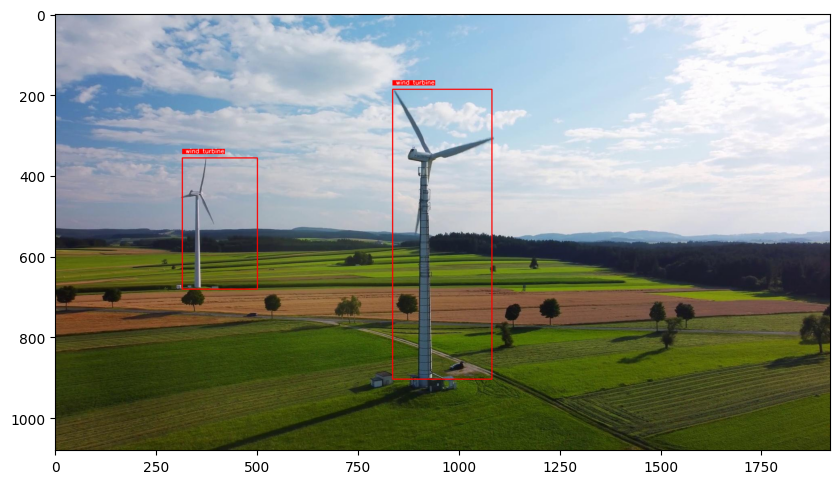

In [12]:
prompt = "detect wind turbine"

opencv_img = cv2.cvtColor(
    cv2.imread("../images/windmill29_jpg.rf.d24acd95b97517c7d47f8f3a79cd01e1.jpg"), cv2.COLOR_BGR2RGB
)

response = get_result(opencv_img, prompt)
print(response)

if "detect" in prompt:
    opencv_img = draw_bounding_boxes(opencv_img, response['boxes'], response['labels'])

plt.figure(figsize=(10, 8))
plt.imshow(opencv_img)
plt.show()



## OCR

![internet service](../wifi.jpg)

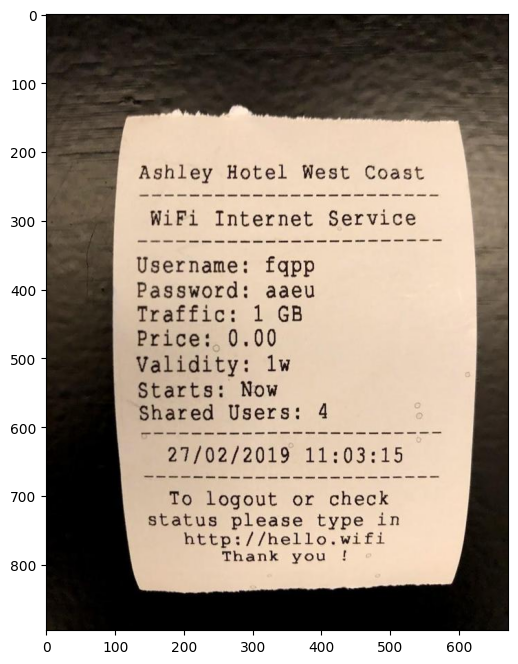

Ashley Hotel West Coast
WiFi Internet Service
Username: fqpp
Password: aaeu
Traffic: 1 GB
Price: 0.00
Validity: 1w
Starts: Now
Shared Users: 4
27/02/2019 11:03:15
To logout or check status please type in http://hello.wifi Thank you !


In [26]:
prompt = "ocr"

opencv_img = cv2.cvtColor(
    cv2.imread("../wifi.jpg"), cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(opencv_img)
plt.show()

response = get_result(opencv_img, prompt)
print(response['paligemma_response'])

## VQA, image caption

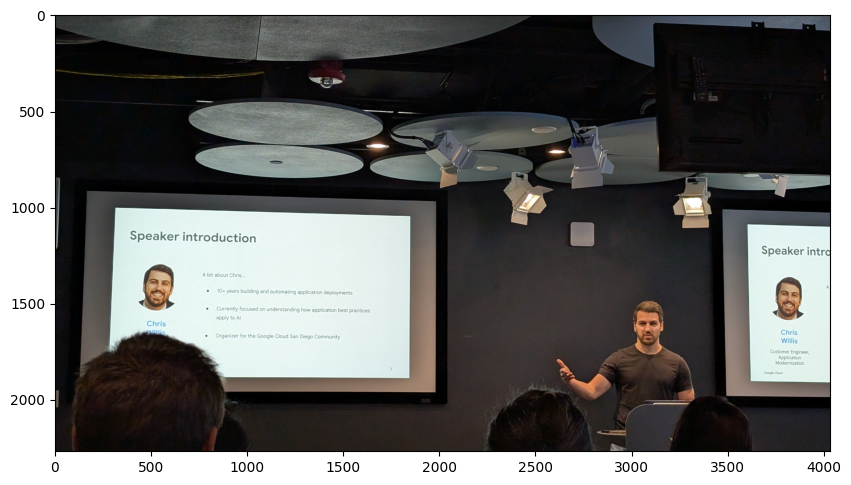

a man is giving a presentation with a slide that says speaker introduction.


In [30]:
prompt = "caption the image"

opencv_img = cv2.cvtColor(
    cv2.imread("../dev_fest.jpg"), cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(opencv_img)
plt.show()

response = get_result(opencv_img, prompt)
print(response['paligemma_response'])